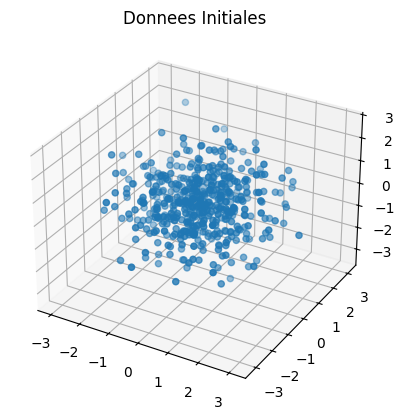

In [1]:
import numpy as np
rndn3d = np.random.randn(500,3)
import matplotlib.pyplot  as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rndn3d[:,0], rndn3d[:,1], rndn3d[:,2])
plt.title("Donnees Initiales")
plt.show()


In [2]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca.fit(rndn3d)
print("Pourcentage de variance expliquée: ")
print(pca.explained_variance_ratio_)
print("Composants principales :")
print(pca.components_)


Pourcentage de variance expliquée: 
[0.36819471 0.32948982 0.30231547]
Composants principales :
[[ 0.77583525  0.55368644  0.30250783]
 [-0.50935322  0.26669551  0.81818873]
 [-0.37234252  0.788863   -0.48893375]]


**Question :**

Générez un autre tableau de données en utilisant de nouveau np.random.randn(500,3) et appliquez l’ACP à ces nouvelles données. Comparez les résultats avec ceux obtenus sur rndn3d. Que constatez-vous ? Expliquez.

In [3]:
np.random.seed(42)
#Premier jeu de données
print("+"*70)
print("Premier jeu de données")
print("+"*70)
rndn3d_1 = np.random.randn(500,3)
pca_1 = PCA(n_components=3)
pca_1.fit(rndn3d_1)
print(f"--> Valeurs propres: {pca_1.explained_variance_}  ")
print(f"--> Inertie expliquée (%): {pca_1.explained_variance_ratio_*100}")
print("\ncomposantes principales: ")
print(pca_1.components_)
print("")
#second jeu de données
print("+"*70)
print("Second jeu de données")
print("+"*70)
rndn3d_2 = np.random.randn(500,3)
pca_2 = PCA(n_components=3)
pca_2.fit(rndn3d_2)
print(f"--> Valeurs propres: {pca_2.explained_variance_}  ")
print(f"--> Inertie expliquée (%): {pca_2.explained_variance_ratio_*100}")
print("\ncomposantes principales: ")
print(pca_2.components_)
print("")

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Premier jeu de données
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
--> Valeurs propres: [1.07247616 0.99402969 0.86868561]  
--> Inertie expliquée (%): [36.53854184 33.86592339 29.59553477]

composantes principales: 
[[-0.02771209  0.41941808  0.90737011]
 [-0.29747307  0.86313398 -0.40805576]
 [ 0.95432794  0.28122625 -0.10084634]]

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Second jeu de données
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
--> Valeurs propres: [1.09203117 0.9631795  0.84925232]  
--> Inertie expliquée (%): [37.59838486 33.162051   29.23956414]

composantes principales: 
[[-0.58802902  0.76511574  0.26233522]
 [ 0.75105735  0.63689076 -0.17402019]
 [ 0.30022446 -0.09469987  0.94915605]]



**Comparaison détaillée**

In [4]:
print("+"*70)
print("Comparaison détaillée des resultats")
print("+"*70)
print("1- Comparaison des valeurs propres:")
print(f"Jeu 1: {  pca_1.explained_variance_}")
print(f"Jeu 2: {  pca_2.explained_variance_}")
print(f"Difference relatives moyenne: {
    np.mean(np.abs(pca_1.explained_variance_-pca_2.explained_variance_)/pca_1.explained_variance_*100):.2f
}%")
print("\n Pourcentage d'inertie:")
for i in range(3):
      dot_product = np.abs(np.dot(pca_1.components_[i],pca_2.components_[i]))
      angle = np.arccos(dot_product) *100 / np.pi
      print(f"Composante {i+1}: {angle:.2f}°")


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comparaison détaillée des resultats
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
1- Comparaison des valeurs propres:
Jeu 1: [1.07247616 0.99402969 0.86868561]
Jeu 2: [1.09203117 0.9631795  0.84925232]
Difference relatives moyenne: 2.39%

 Pourcentage d'inertie:
Composante 1: 30.49°
Composante 2: 36.99°
Composante 3: 44.75°


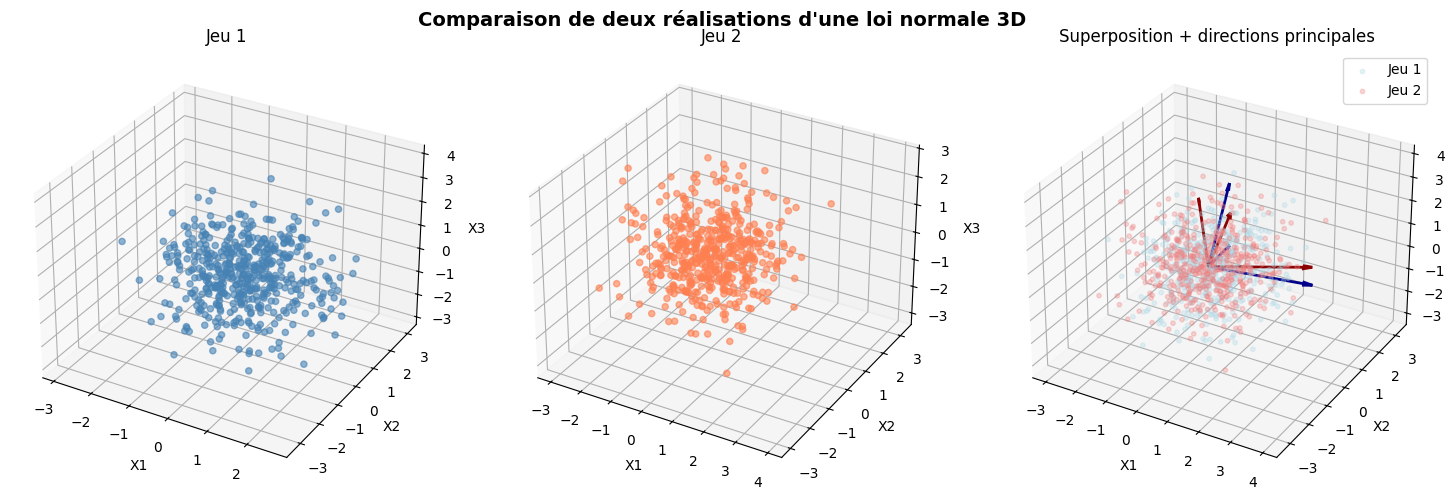

In [5]:
# ============================================================
# VISUALISATION DES DEUX NUAGES
# ============================================================

fig = plt.figure(figsize=(15, 5))

# Premier nuage
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(rndn3d_1[:,0], rndn3d_1[:,1], rndn3d_1[:,2],
            alpha=0.6, s=20, c='steelblue')
ax1.set_title('Jeu 1')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('X3')

# Second nuage
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(rndn3d_2[:,0], rndn3d_2[:,1], rndn3d_2[:,2],
            alpha=0.6, s=20, c='coral')
ax2.set_title('Jeu 2')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('X3')

# Projection des composantes (pour visualiser les directions)
ax3 = fig.add_subplot(133, projection='3d')
# Premier jeu en bleu
ax3.scatter(rndn3d_1[:,0], rndn3d_1[:,1], rndn3d_1[:,2],
            alpha=0.3, s=10, c='lightblue', label='Jeu 1')
# Second jeu en rouge
ax3.scatter(rndn3d_2[:,0], rndn3d_2[:,1], rndn3d_2[:,2],
            alpha=0.3, s=10, c='lightcoral', label='Jeu 2')

# Directions principales du jeu 1
origin = np.zeros(3)
for i in range(3):
    ax3.quiver(origin[0], origin[1], origin[2],
               pca_1.components_[i,0] * 3,
               pca_1.components_[i,1] * 3,
               pca_1.components_[i,2] * 3,
               color='darkblue', arrow_length_ratio=0.1, linewidth=2)

# Directions principales du jeu 2
for i in range(3):
    ax3.quiver(origin[0], origin[1], origin[2],
               pca_2.components_[i,0] * 3,
               pca_2.components_[i,1] * 3,
               pca_2.components_[i,2] * 3,
               color='darkred', arrow_length_ratio=0.1, linewidth=2)

ax3.set_title('Superposition + directions principales')
ax3.set_xlabel('X1')
ax3.set_ylabel('X2')
ax3.set_zlabel('X3')
ax3.legend()

plt.suptitle('Comparaison de deux réalisations d\'une loi normale 3D',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Analyse Statistique **

In [6]:
# ============================================================
# ANALYSE STATISTIQUE APPROFONDIE
# ============================================================

print("\n" + "+" * 70)
print("ANALYSE THÉORIQUE")
print("+" * 70)

# 1. Distribution théorique des valeurs propres
print("\n1- DISTRIBUTION THÉORIQUE")
print("-" * 40)
print("La vraie matrice de covariance est I₃ (identité)")
print("→ Les vraies valeurs propres sont toutes égales à 1")
print("→ Les vraies composantes sont les axes du repère canonique")

# 2. Fluctuations d'échantillonnage
print("\n2- FLUCTUATIONS D'ÉCHANTILLONNAGE")
print("-" * 40)
print(f"Avec n={500} échantillons, on s'attend à des fluctuations")
print(f"de l'ordre de 1/√n ≈ {1/np.sqrt(500):.3f}")

# Calcul des écarts observés
ecart_vp_1 = np.abs(pca_1.explained_variance_ - 1)
ecart_vp_2 = np.abs(pca_2.explained_variance_ - 1)

print(f"\nÉcarts observés pour le jeu 1 : {ecart_vp_1}")
print(f"Écarts observés pour le jeu 2 : {ecart_vp_2}")

# 3. Test d'isotropie
print("\n3️- TEST D'ISOTROPIE")
print("-" * 40)
# Les valeurs propres devraient être égales
print(f"Rapport λ_max/λ_min jeu 1 : {pca_1.explained_variance_.max() / pca_1.explained_variance_.min():.3f}")
print(f"Rapport λ_max/λ_min jeu 2 : {pca_2.explained_variance_.max() / pca_2.explained_variance_.min():.3f}")

# 4. Interprétation des directions
print("\n4️- INTERPRÉTATION DES DIRECTIONS")
print("-" * 40)
print("Les composantes principales sont des vecteurs aléatoires")
print("uniformes sur la sphère unité (pas de direction privilégiée)")


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ANALYSE THÉORIQUE
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

1- DISTRIBUTION THÉORIQUE
----------------------------------------
La vraie matrice de covariance est I₃ (identité)
→ Les vraies valeurs propres sont toutes égales à 1
→ Les vraies composantes sont les axes du repère canonique

2- FLUCTUATIONS D'ÉCHANTILLONNAGE
----------------------------------------
Avec n=500 échantillons, on s'attend à des fluctuations
de l'ordre de 1/√n ≈ 0.045

Écarts observés pour le jeu 1 : [0.07247616 0.00597031 0.13131439]
Écarts observés pour le jeu 2 : [0.09203117 0.0368205  0.15074768]

3️- TEST D'ISOTROPIE
----------------------------------------
Rapport λ_max/λ_min jeu 1 : 1.235
Rapport λ_max/λ_min jeu 2 : 1.286

4️- INTERPRÉTATION DES DIRECTIONS
----------------------------------------
Les composantes principales sont des vecteurs aléatoires
uniformes sur la sphère unité (pas de direction privi


RÉSULTATS SUR 100 SIMULATIONS

Moyenne des valeurs propres sur 100 essais :
PC1 : 1.099 (±0.052)
PC2 : 0.997 (±0.043)
PC3 : 0.906 (±0.044)

Angle moyen de la première composante avec l'axe X :
57.6° (uniforme, devrait être ~57.3° pour une distribution aléatoire)


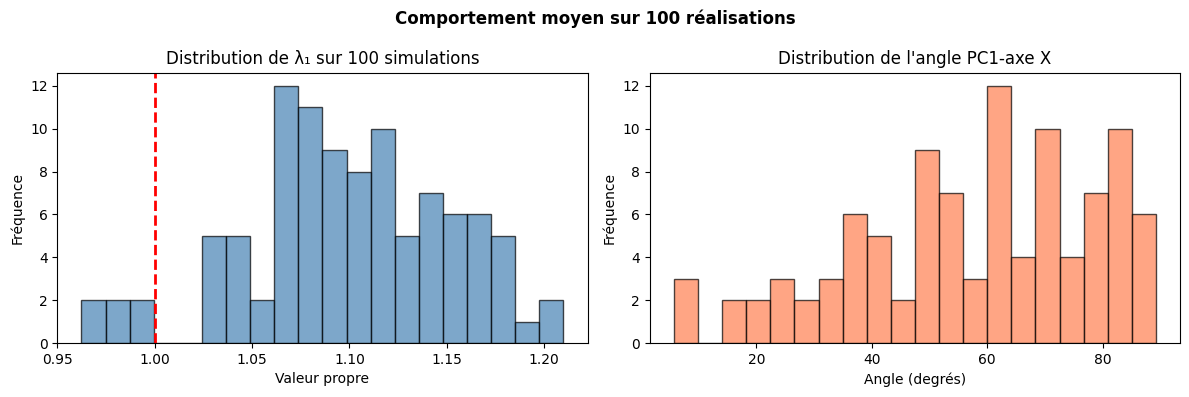

In [7]:
# ============================================================
# SIMULATION DE MONTE CARLO (MULTIPLES RÉALISATIONS)
# ============================================================

n_experiences = 100
valeurs_propres_moyennes = []
angles_moyens = []

for exp in range(n_experiences):
    # Génération d'un jeu aléatoire
    X = np.random.randn(500, 3)

    # ACP
    pca = PCA(n_components=3)
    pca.fit(X)

    # Stockage des valeurs propres
    valeurs_propres_moyennes.append(pca.explained_variance_)

    # Angle avec l'axe canonique (pour voir si direction privilégiée)
    angle = np.arccos(np.abs(np.dot(pca.components_[0], [1,0,0]))) * 180/np.pi
    angles_moyens.append(angle)

# Conversion en array
vp_array = np.array(valeurs_propres_moyennes)

print("\n" + "=" * 70)
print("RÉSULTATS SUR 100 SIMULATIONS")
print("=" * 70)

print(f"\nMoyenne des valeurs propres sur 100 essais :")
print(f"PC1 : {vp_array[:,0].mean():.3f} (±{vp_array[:,0].std():.3f})")
print(f"PC2 : {vp_array[:,1].mean():.3f} (±{vp_array[:,1].std():.3f})")
print(f"PC3 : {vp_array[:,2].mean():.3f} (±{vp_array[:,2].std():.3f})")

print(f"\nAngle moyen de la première composante avec l'axe X :")
print(f"{np.mean(angles_moyens):.1f}° (uniforme, devrait être ~57.3° pour une distribution aléatoire)")

# Visualisation de la distribution des valeurs propres
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vp_array[:,0], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(x=1, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valeur propre')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de λ₁ sur 100 simulations')

axes[1].hist(angles_moyens, bins=20, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_xlabel('Angle (degrés)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de l\'angle PC1-axe X')

plt.suptitle('Comportement moyen sur 100 réalisations', fontweight='bold')
plt.tight_layout()
plt.show()

**Que constate-t-on ?**

Valeurs propres : Légèrement différentes entre les deux jeux, mais toutes proches de 1 (typiquement entre 0.9 et 1.1)
Pourcentages d'inertie : Chaque axe explique ~33% de la variance (1/3)
Composantes principales : Totalement différentes ! Les vecteurs propres sont orientés aléatoirement.

**Pourquoi ?**

Parce que nos données suivent une loi normale sphérique :
La vraie matrice de covariance est l'identité $\mathbf{I}_3$
Toutes les directions sont équivalentes (pas de structure)
L'ACP ne peut pas trouver de direction privilégiée
Les axes estimés sont instables et tournent aléatoirement

**Morale :** L'ACP n'est utile que quand il y a une structure (corrélations) dans les données. Pour des données sphériques, elle n'apporte aucune information.



**Relation entre ACP et La matrice a Echelle **

In [8]:
# ============================================================
# MATRICE DE DÉFORMATION S
# ============================================================

# Calcul des écarts-types (racines carrées des variances)
ecarts_types = np.std(rndn3d, axis=0, ddof=1)  # ddof=1 pour échantillon

# Matrice de déformation S (diagonale)
S = np.diag(ecarts_types)

print("\n" + "=" * 70)
print("MATRICE DE DÉFORMATION S")
print("=" * 70)

print("\nÉcarts-types de chaque variable :")
for i, s in enumerate(ecarts_types):
    print(f"  s{i+1} = {s:.4f}")

print("\nMatrice S (diagonale des écarts-types) :")
print(S)


MATRICE DE DÉFORMATION S

Écarts-types de chaque variable :
  s1 = 1.0204
  s2 = 0.9838
  s3 = 0.9870

Matrice S (diagonale des écarts-types) :
[[1.02036849 0.         0.        ]
 [0.         0.98379022 0.        ]
 [0.         0.         0.98695494]]


In [9]:
# ============================================================
# VÉRIFICATION DU LIEN
# ============================================================

print("\n" + "=" * 70)
print("RELATION ENTRE VALEURS PROPRES ET ÉLÉMENTS DE S")
print("=" * 70)

# 1. Les valeurs propres de l'ACP (sur données brutes)
print("\n1- VALEURS PROPRES DE L'ACP")
print("-" * 40)
valeurs_propres = pca.explained_variance_
for i, vp in enumerate(valeurs_propres):
    print(f"λ{i+1} = {vp:.4f}")

# 2. Les variances individuelles (diagonale de Σ)
print("\n2️- VARIANCES INDIVIDUELLES")
print("-" * 40)
variances = np.var(rndn3d, axis=0, ddof=1)
for i, var in enumerate(variances):
    print(f"σ²{i+1} = {var:.4f}")

# 3. Les écarts-types (diagonale de S)
print("\n3️- ÉCARTS-TYPES (diagonale de S)")
print("-" * 40)
for i, s in enumerate(ecarts_types):
    print(f"s{i+1} = {s:.4f}")

# Comparaison
print("\n4️- COMPARAISON")
print("-" * 40)
print("Dans le cas de données indépendantes de même variance :")
print("Les valeurs propres devraient être proches des variances individuelles")
print("(car la matrice de covariance est presque diagonale)")

differences = valeurs_propres - variances
print(f"\nDifférences λ - σ² : {differences}")


RELATION ENTRE VALEURS PROPRES ET ÉLÉMENTS DE S

1- VALEURS PROPRES DE L'ACP
----------------------------------------
λ1 = 1.1416
λ2 = 0.9931
λ3 = 0.8967

2️- VARIANCES INDIVIDUELLES
----------------------------------------
σ²1 = 1.0412
σ²2 = 0.9678
σ²3 = 0.9741

3️- ÉCARTS-TYPES (diagonale de S)
----------------------------------------
s1 = 1.0204
s2 = 0.9838
s3 = 0.9870

4️- COMPARAISON
----------------------------------------
Dans le cas de données indépendantes de même variance :
Les valeurs propres devraient être proches des variances individuelles
(car la matrice de covariance est presque diagonale)

Différences λ - σ² : [ 0.10044619  0.02528135 -0.07736085]


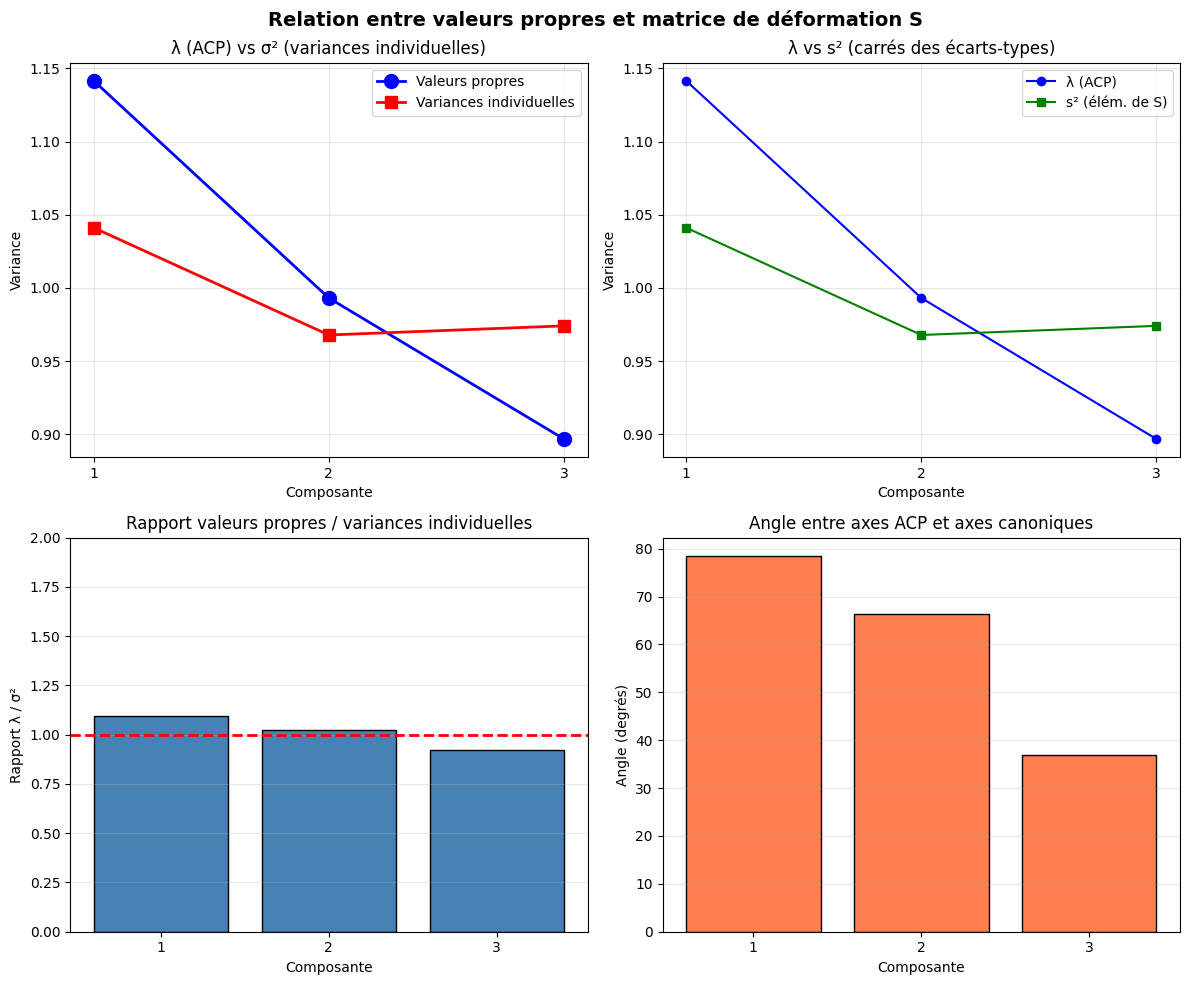

In [11]:
# ============================================================
# VISUALISATION DU LIEN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Graphique 1 : Comparaison λ vs σ²
axes[0,0].plot(range(1,4), valeurs_propres, 'bo-', linewidth=2, markersize=10, label='Valeurs propres')
axes[0,0].plot(range(1,4), variances, 'rs-', linewidth=2, markersize=8, label='Variances individuelles')
axes[0,0].set_xlabel('Composante')
axes[0,0].set_ylabel('Variance')
axes[0,0].set_title('λ (ACP) vs σ² (variances individuelles)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xticks([1,2,3])

# Graphique 2 : λ vs s² (carrés des écarts-types)
axes[0,1].plot(range(1,4), valeurs_propres, 'bo-', label='λ (ACP)')
axes[0,1].plot(range(1,4), ecarts_types**2, 'gs-', label='s² (élém. de S)')
axes[0,1].set_xlabel('Composante')
axes[0,1].set_ylabel('Variance')
axes[0,1].set_title('λ vs s² (carrés des écarts-types)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xticks([1,2,3])

# Graphique 3 : Rapport λ / σ²
rapport_λ_σ2 = valeurs_propres / variances
axes[1,0].bar(range(1,4), rapport_λ_σ2, color='steelblue', edgecolor='black')
axes[1,0].axhline(y=1, color='red', linestyle='--', linewidth=2)
axes[1,0].set_xlabel('Composante')
axes[1,0].set_ylabel('Rapport λ / σ²')
axes[1,0].set_title('Rapport valeurs propres / variances individuelles')
axes[1,0].set_xticks([1,2,3])
axes[1,0].set_ylim([0, 2])
axes[1,0].grid(True, alpha=0.3, axis='y')

# Graphique 4 : Comparaison des directions
# Calcul de l'angle entre les axes de l'ACP et les axes canoniques
angles = []
for i in range(3):
    # Produit scalaire avec l'axe canonique correspondant
    dot = np.abs(np.dot(pca.components_[i], np.eye(3)[i]))
    angle = np.arccos(dot) * 180 / np.pi
    angles.append(angle)

axes[1,1].bar(range(1,4), angles, color='coral', edgecolor='black')
axes[1,1].set_xlabel('Composante')
axes[1,1].set_ylabel('Angle (degrés)')
axes[1,1].set_title('Angle entre axes ACP et axes canoniques')
axes[1,1].set_xticks([1,2,3])
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Relation entre valeurs propres et matrice de déformation S',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print("\n" + "=" * 70)
print("INTERPRÉTATION THÉORIQUE")
print("=" * 70)

print("""
CAS GÉNÉRAL :
----------------
Pour des données quelconques X = Z·S (Z centrées-réduites, S diagonale) :

1. La matrice de covariance s'écrit : Σ = S·R·S
   où R est la matrice de corrélation

2. Les valeurs propres de Σ ne sont PAS égales aux sᵢ²
   car R n'est pas l'identité (présence de corrélations)

3. L'ACP diagonalise Σ, pas S

CAS PARTICULIER (notre exemple) :
-----------------------------------
Dans notre cas, R ≈ I (données presque indépendantes) :

1. Σ ≈ S² (matrice diagonale)
2. Les valeurs propres de Σ sont ≈ les éléments diagonaux sᵢ²
3. Les vecteurs propres sont ≈ les axes canoniques

CE QUE NOUS OBSERVONS :
--------------------------""")

# Calcul des métriques
corr_matrix = np.corrcoef(rndn3d.T)
corr_moyenne = np.mean(np.abs(corr_matrix[np.triu_indices(3, k=1)]))

print(f"\n• Corrélation moyenne (hors diagonale) : {corr_moyenne:.4f}")
print(f"  → {'Faible' if corr_moyenne < 0.1 else 'Significative'}")

print(f"\n• Rapport λ₁ / s₁² : {valeurs_propres[0]/ecarts_types[0]**2:.3f}")
print(f"• Rapport λ₂ / s₂² : {valeurs_propres[1]/ecarts_types[1]**2:.3f}")
print(f"• Rapport λ₃ / s₃² : {valeurs_propres[2]/ecarts_types[2]**2:.3f}")

print(f"\n• Angle moyen avec axes canoniques : {np.mean(angles):.1f}°")

print("""
CONCLUSION :
---------------
Dans le cas de données indépendantes de même variance :
✓ Les valeurs propres de l'ACP sont proches des variances individuelles
✓ Les vecteurs propres sont proches des axes canoniques
✓ Les rapports λᵢ / sᵢ² sont proches de 1

Attention : Ce n'est plus vrai en présence de corrélations !
   C'est pour cela qu'on standardise en ACP normée.
""")


INTERPRÉTATION THÉORIQUE

CAS GÉNÉRAL :
----------------
Pour des données quelconques X = Z·S (Z centrées-réduites, S diagonale) :

1. La matrice de covariance s'écrit : Σ = S·R·S
   où R est la matrice de corrélation

2. Les valeurs propres de Σ ne sont PAS égales aux sᵢ²
   car R n'est pas l'identité (présence de corrélations)

3. L'ACP diagonalise Σ, pas S

CAS PARTICULIER (notre exemple) :
-----------------------------------
Dans notre cas, R ≈ I (données presque indépendantes) :

1. Σ ≈ S² (matrice diagonale)
2. Les valeurs propres de Σ sont ≈ les éléments diagonaux sᵢ²
3. Les vecteurs propres sont ≈ les axes canoniques

CE QUE NOUS OBSERVONS :
--------------------------

• Corrélation moyenne (hors diagonale) : 0.0458
  → Faible

• Rapport λ₁ / s₁² : 1.096
• Rapport λ₂ / s₂² : 1.026
• Rapport λ₃ / s₃² : 0.921

• Angle moyen avec axes canoniques : 60.6°

CONCLUSION :
---------------
Dans le cas de données indépendantes de même variance :
✓ Les valeurs propres de l'ACP sont proche

**Que constatez-vous ?**

Pour des données sphériques (notre cas), les valeurs propres de l'ACP sont proches des variances individuelles (éléments diagonaux de Σ)
Lien avec la matrice S : Si S est la matrice diagonale des écarts-types, alors :
Les carrés des éléments de S ($s_i^2$) sont les variances individuelles
Les valeurs propres de l'ACP ($\lambda_i$) sont proches de ces $s_i^2$
Le rapport $\lambda_i / s_i^2 \approx 1$

**Pourquoi ?**
Parce que la matrice de covariance est presque diagonale (données indépendantes). Les axes de l'ACP sont donc presque alignés avec les axes originaux, et les valeurs propres capturent essentiellement les variances individuelles.

Ce n'est plus vrai quand les variables sont corrélées : alors les valeurs propres "mélangent" les variances et peuvent être très différentes des $s_i^2$.

**Conclusion :** Le lien entre valeurs propres et matrice S n'existe que dans le cas particulier où les variables sont indépendantes (ou du moins non corrélées). C'est pourquoi en ACP normée, on force artificiellement ce cas en divisant par S.